In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

Failed to open ATL03 file for sodankyla_full file 4's beam 3.
Failed to open ATL03 file for sodankyla_full file 4's beam 5.


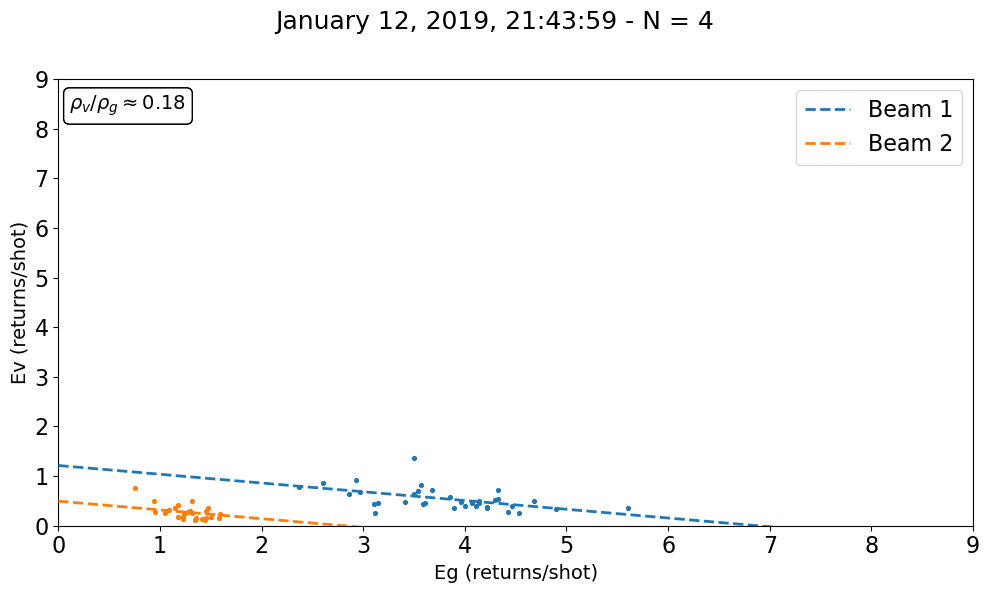

In [77]:
import yaml

with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

from scripts.parallel_blocks_refactor import *

dirpath = '../../data_store/data/sodankyla_full/'

all_ATL03, all_ATL08, failed_ATL03 = track_pairs(dirpath, failed=True)
N = len(all_ATL03)

coords = (26.634154, 67.361833)

cfg['parallel_blocks']['small_box_half_side'] = 4 + 1e-8
cfg['parallel_blocks']['rebinned'] = 20

for i in [4]:
    data = pvpg_parallel(dirpath, all_ATL03[i], all_ATL08[i], coords=coords, cfg=cfg, file_index=i, graph_detail=1)

In [80]:
data[30:]

,camera,date,lon,lat,pvpg,pv,pg,Eg,Ev,data_quantity,...,snr,segment_cover,segment_landcover,h_te_best_fit,h_te_std,terrain_slope,longitude,latitude,cloud_flag_atm,layer_flag
30,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,2.37037,0.777778,37,...,147.488327,65.0,111.0,206.238284,0.457588,-0.06093,26.724832,67.338919,1.0,1.0
31,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,3.142857,0.464286,37,...,147.488327,65.0,111.0,205.465933,0.259573,-0.029365,26.724778,67.338742,1.0,1.0
32,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,3.407407,0.481481,37,...,147.488327,56.0,126.0,204.693582,0.23232,-0.024631,26.724723,67.338565,1.0,1.0
33,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,4.071429,0.464286,37,...,147.488327,56.0,126.0,203.921231,0.257995,-0.032676,26.724669,67.338388,1.0,1.0
34,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,3.892857,0.357143,37,...,147.488327,90.0,111.0,218.415533,0.503982,0.077948,26.723438,67.334283,1.0,1.0
35,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,3.5,1.357143,37,...,147.488327,94.0,111.0,220.344827,0.998262,0.154999,26.723383,67.334105,1.0,1.0
36,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,1.21322,6.879143,4.428571,0.285714,37,...,147.488327,94.0,111.0,224.203415,0.308144,0.041348,26.723274,67.333748,1.0,1.0
37,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,0.494443,2.80357,1.346154,0.115385,26,...,72.546013,71.0,111.0,206.203955,0.235839,-0.021609,26.727723,67.354503,1.0,1.0
38,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,0.494443,2.80357,1.578947,0.157895,26,...,72.546013,71.0,111.0,206.264041,0.310555,-0.042295,26.72767,67.354326,1.0,1.0
39,sodankyla_full,12/01/2019,26.726215,67.361833,0.176362,0.494443,2.80357,0.75,0.75,26,...,72.546013,88.0,111.0,209.211746,0.474989,0.06517,26.727038,67.352222,1.0,1.0


In [76]:
data.explode([c for c in data.columns if isinstance(data[c].iloc[0], list)], ignore_index=True).iloc[0]

camera               sodankyla_full
date                     12/01/2019
lon                       26.726215
lat                       67.361833
pvpg                       0.176362
pv                          1.21322
pg                         6.879143
Eg                         4.896552
Ev                         0.344828
data_quantity                    37
altitude                       None
pv_ratio_mean              2.453709
pv_ratio_max               2.453709
beam                              1
beam_str                     strong
outlier                           1
msw_flag                        1.0
night_flag                      1.0
asr                        0.291901
canopy_openness            3.668004
snr                      147.488327
segment_cover                  93.0
segment_landcover             111.0
h_te_best_fit            210.869937
h_te_std                   0.240969
terrain_slope              0.025768
longitude                 26.727727
latitude                   6

In [15]:
cfg

{'parallel_blocks': {'w': [1.0, 0.25],
  'slope_init': -1,
  'slope_lb': -100,
  'slope_ub': -0.01,
  'loss': 'linear',
  'f_scale': 0.1,
  'outlier_removal': False,
  'roi_half_width': 4,
  'roi_half_height': 4,
  'small_box_side': 4.00000001,
  'altitude': None,
  'alt_thresh': None,
  'insufficient_data_threshold': 1,
  'landcover': 'forest',
  'trim_atmospheric': False,
  'sat_flag': False,
  'DW': False,
  'rebinned': 0,
  'res_field': 'alongtrack',
  'canopy_frac': None,
  'terrain_frac': None}}